In [10]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, VelocityState, angle_abc, euclid_center_distance, axial_to_xy
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution, BidHStarSearch, radius_from_angle
from hexplot import plot_hex_grid_2
import math
from dataclasses import dataclass
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

In [11]:
import pandas as pd
import numpy as np
import math

In [12]:
def calculate_turning_radius_from_coords(
    parent_location: HexCoord,
    node_location: HexCoord,
    child_location: HexCoord,
    *,
    hex_size: float = 1.0,
) -> float:
    """
    Calculate the turning radius at node_location for three consecutive
    HexCoord locations.
    """
    angle = angle_abc(
        parent_location,
        node_location,
        child_location,
        hex_size=hex_size,
    )

    edge_1 = euclid_center_distance(
        parent_location,
        node_location,
        hex_size=hex_size,
    )
    

    edge_2 = euclid_center_distance(
        node_location,
        child_location,
        hex_size=hex_size,
    )

    return radius_from_angle(
        min(edge_1, edge_2),
        angle,
    )

In [13]:
parent_location = HexCoord(-1, 0)
node_location = HexCoord(0, 0)
child_location = HexCoord(0, 1)

radius = calculate_turning_radius_from_coords(
    parent_location,
    node_location,
    child_location,
    hex_size=1.0,
)

print(radius)

1.7320508075688779


In [14]:
edge_length = 1
n = 12
edge_length / (2 * math.sin(math.pi / n))

1.9318516525781368

In [15]:
TRANSITIONS = [
    {
        "title": "Sharp Right (-60°)",
        "path": [
            HexCoord(-1,0),
            HexCoord(0,0),
            HexCoord(0,1),
        ],
    },
    {
        "title": "Zig-Zag Right (-30°)",
        "path": [
            HexCoord(-1,0),
            HexCoord(0,0),
            HexCoord(1,1),
        ],
    },
    {
        "title": "Straight (0°)",
        "path": [
            HexCoord(-1,0),
            HexCoord(0,0),
            HexCoord(1,0),
        ],
    },
    {
        "title": "Zig-Zag Left (+30°)",
        "path": [
            HexCoord(-1,0),
            HexCoord(0,0),
            HexCoord(2,-1),
        ],
    },
    {
        "title": "Sharp Left (+60°)",
        "path": [
            HexCoord(-1,0),
            HexCoord(0,0),
            HexCoord(1,-1),
        ],
    },
]

In [16]:
TRANSITIONS[0]["path"]

[HexCoord(q=-1, r=0), HexCoord(q=0, r=0), HexCoord(q=0, r=1)]

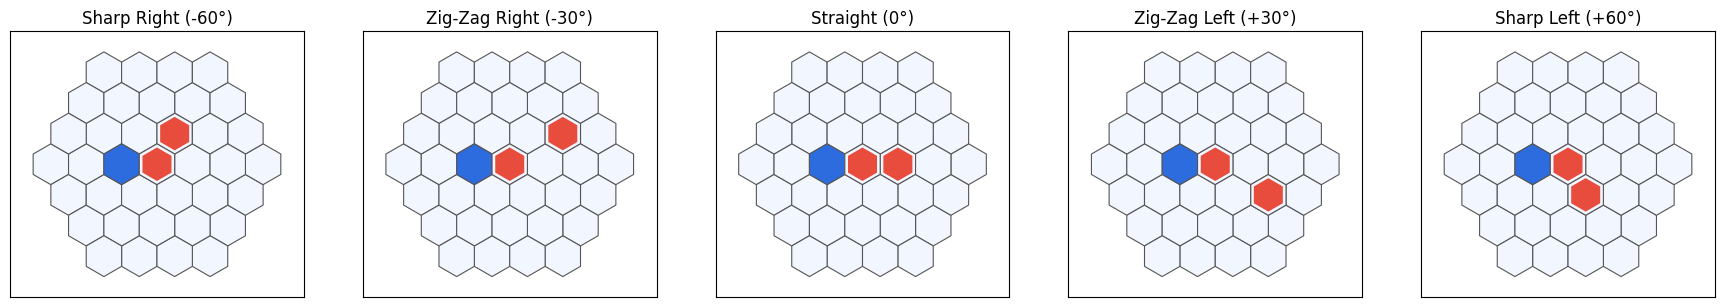

In [17]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(22,5),
)

for ax, transition in zip(axes, TRANSITIONS):

    plot_hex_grid_2(
        obstacles=[],
        start=HexCoord(-1,0),
        center=HexCoord(0,0),
        radius=3,
        path=transition["path"],
        ax=ax,
        show_coords=False,
        show_axis_legend=False,
        draw_axes=False,
        plt_title=transition["title"],
    )

